In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import os

# Set plotting style for Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

### Load the Dataset

In [2]:
print("Loading dataset...")

# --- DEVELOPER CONTROLS ---
# Set this to an integer (e.g., 2000, 5000) for fast training during development.
# Set it to None to use the entire dataset for final evaluation.
MAX_TRAIN_SAMPLES = 3000
# --------------------------

# Load the raw files
X_train_raw = pd.read_csv('../data/processed/X_train.csv')
X_test_raw = pd.read_csv('../data/processed/X_test.csv')
y_train_raw = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_raw = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Original Training set shape: {X_train_raw.shape}")

# Subsample the training data if MAX_TRAIN_SAMPLES is set
if MAX_TRAIN_SAMPLES and MAX_TRAIN_SAMPLES < len(X_train_raw):
    print(f"\n[!] Subsampling training data to {MAX_TRAIN_SAMPLES} samples for faster training...")

    # We sample indices first to ensure X and y remain perfectly aligned
    sampled_indices = X_train_raw.sample(n=MAX_TRAIN_SAMPLES, random_state=42).index

    X = X_train_raw.loc[sampled_indices].copy()
    y = y_train_raw.loc[sampled_indices].copy()
else:
    X = X_train_raw.copy()
    y = y_train_raw.copy()

# We usually leave the test set whole to ensure consistent evaluation metrics,
# but we assign them to our standard variable names here.
y_test = y_test_raw
y_train = y

print(f"Final Training features shape: {X.shape}")
print(f"Test features shape: {X_test_raw.shape}")

Loading dataset...
Original Training set shape: (31715, 58)

[!] Subsampling training data to 3000 samples for faster training...
Final Training features shape: (3000, 58)
Test features shape: (7929, 58)


### Standardize the Features

In [3]:
print("\n--- Feature Standardization Analysis ---")

# Compute before/after standardization stats
before_stats = pd.DataFrame({
    "min_before": X.min(),
    "max_before": X.max()
})
before_stats["range_before"] = before_stats["max_before"] - before_stats["min_before"]

# After standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Also scale the test set!
X_test_scaled = scaler.transform(X_test_raw)
X_train = X_scaled  # Reassign for later model training use

after_stats = pd.DataFrame({
    "min_after": X_scaled_df.min(),
    "max_after": X_scaled_df.max()
})
after_stats["range_after"] = after_stats["max_after"] - after_stats["min_after"]

# Combined table
range_comparison = before_stats.join(after_stats)

print("Feature range comparison (before vs after standardization):")
display_df = range_comparison.sort_values("range_before", ascending=False).head(10)
display(display_df)

print("\nSummary:")
print("Mean range before:", range_comparison["range_before"].mean())
print("Mean range after :", range_comparison["range_after"].mean())

print("\nClass distribution: Train set")
print(y_train.value_counts().sort_index())
print("Class distribution: Test set")
print(y_test.value_counts().sort_index())


--- Feature Standardization Analysis ---
Feature range comparison (before vs after standardization):


,min_before,max_before,range_before,min_after,max_after,range_after
self_reference_max_shares,0.0,843300.000000,843300.000000,-0.265714,19.836339,20.102053
kw_min_max,0.0,843300.000000,843300.000000,-0.249924,17.513724,17.763648
kw_max_max,0.0,843300.000000,843300.000000,-3.594369,0.421619,4.015989
kw_avg_max,0.0,843300.000000,843300.000000,-1.979068,4.493047,6.472115
self_reference_avg_sharess,0.0,423100.000000,423100.000000,-0.344591,21.978498,22.323089
self_reference_min_shares,0.0,196700.000000,196700.000000,-0.358299,18.859381,19.217680
kw_max_avg,0.0,121633.333333,121633.333333,-1.052085,21.555369,22.607454
kw_max_min,0.0,98700.000000,98700.000000,-0.418174,37.695484,38.113658
kw_avg_avg,0.0,27391.598396,27391.598396,-2.377991,18.333892,20.711882
kw_avg_min,-1.0,14187.798571,14188.798571,-0.737689,34.004183,34.741872



Summary:
Mean range before: 73512.20384297089
Mean range after : 8.28949626905182

Class distribution: Train set
popularity
0    1411
1    1589
Name: count, dtype: int64
Class distribution: Test set
popularity
0    3698
1    4231
Name: count, dtype: int64


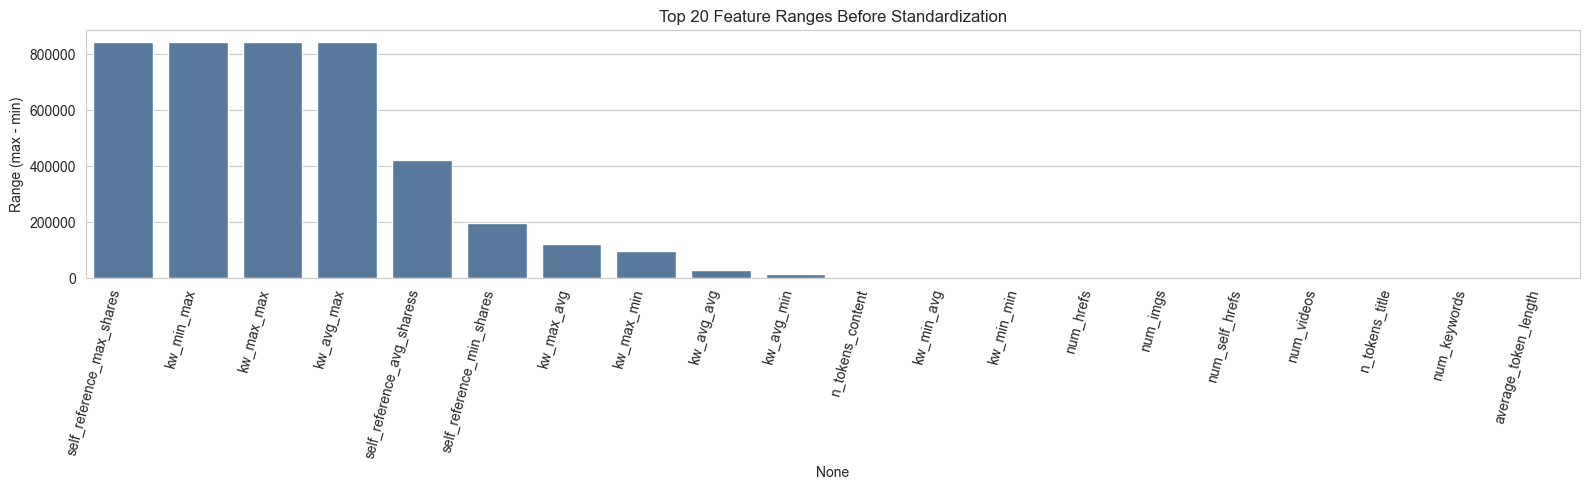

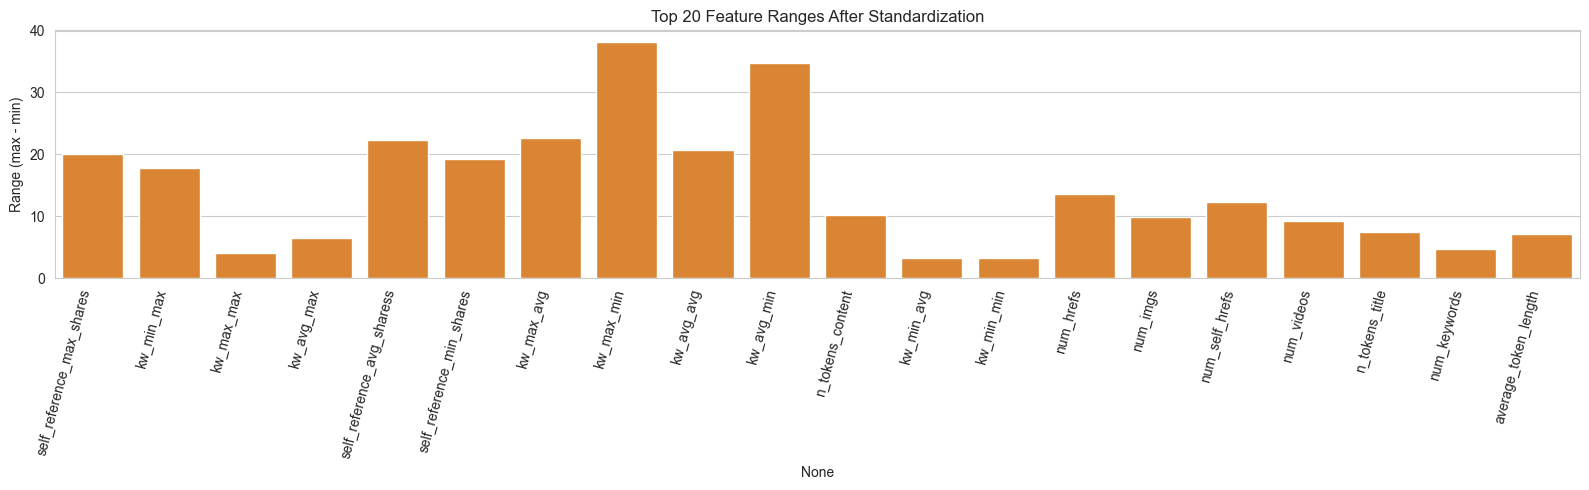

In [4]:
# Plot graphs separately
os.makedirs('../docs/svm_plots', exist_ok=True)

# Graph 1A: Feature ranges BEFORE standardization (Top 20 features)
top_20_features = range_comparison.sort_values("range_before", ascending=False).head(20)

plt.figure(figsize=(16, 5))
sns.barplot(
    x=top_20_features.index,
    y=top_20_features["range_before"],
    color="#4C78A8"
)
plt.title("Top 20 Feature Ranges Before Standardization")
plt.ylabel("Range (max - min)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig('../docs/svm_plots/ranges_before.png')
plt.show()

# Graph 1B: Feature ranges AFTER standardization (Top 20 features)
plt.figure(figsize=(16, 5))
sns.barplot(
    x=top_20_features.index,
    y=range_comparison.loc[top_20_features.index, "range_after"],
    color="#F58518"
)
plt.title("Top 20 Feature Ranges After Standardization")
plt.ylabel("Range (max - min)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig('../docs/svm_plots/ranges_after.png')
plt.show()

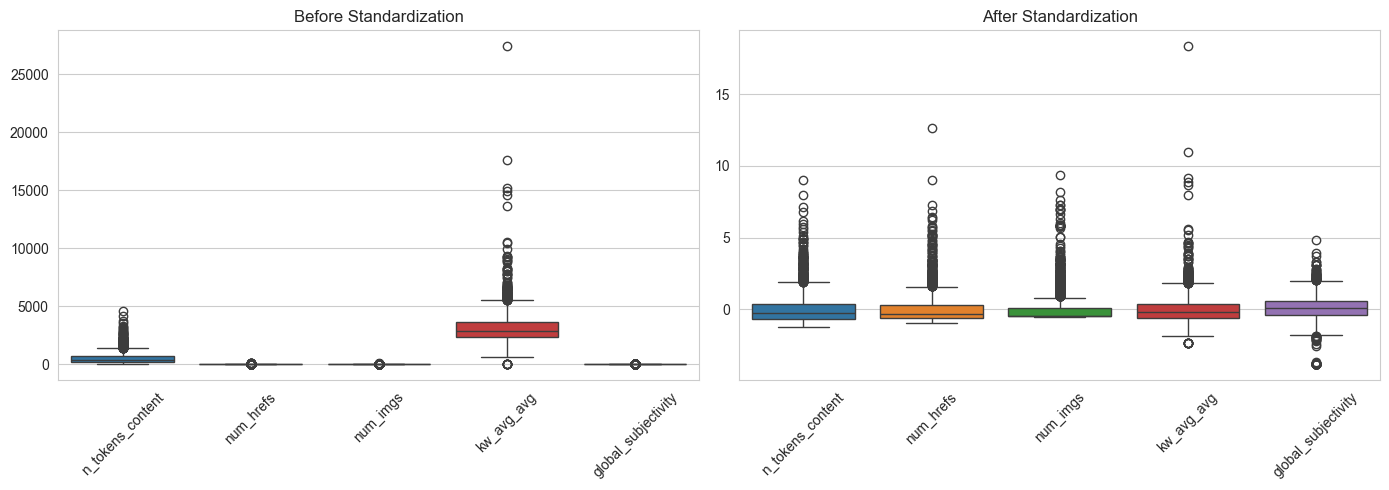

In [5]:
# Graph 2: Distribution comparison (raw vs standardized) for selected continuous features
plot_features = [
    "n_tokens_content",
    "num_hrefs",
    "num_imgs",
    "kw_avg_avg",
    "global_subjectivity",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=X[plot_features], ax=axes[0])
axes[0].set_title("Before Standardization")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=X_scaled_df[plot_features], ax=axes[1])
axes[1].set_title("After Standardization")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig('../docs/svm_plots/distribution_comparison.png')
plt.show()

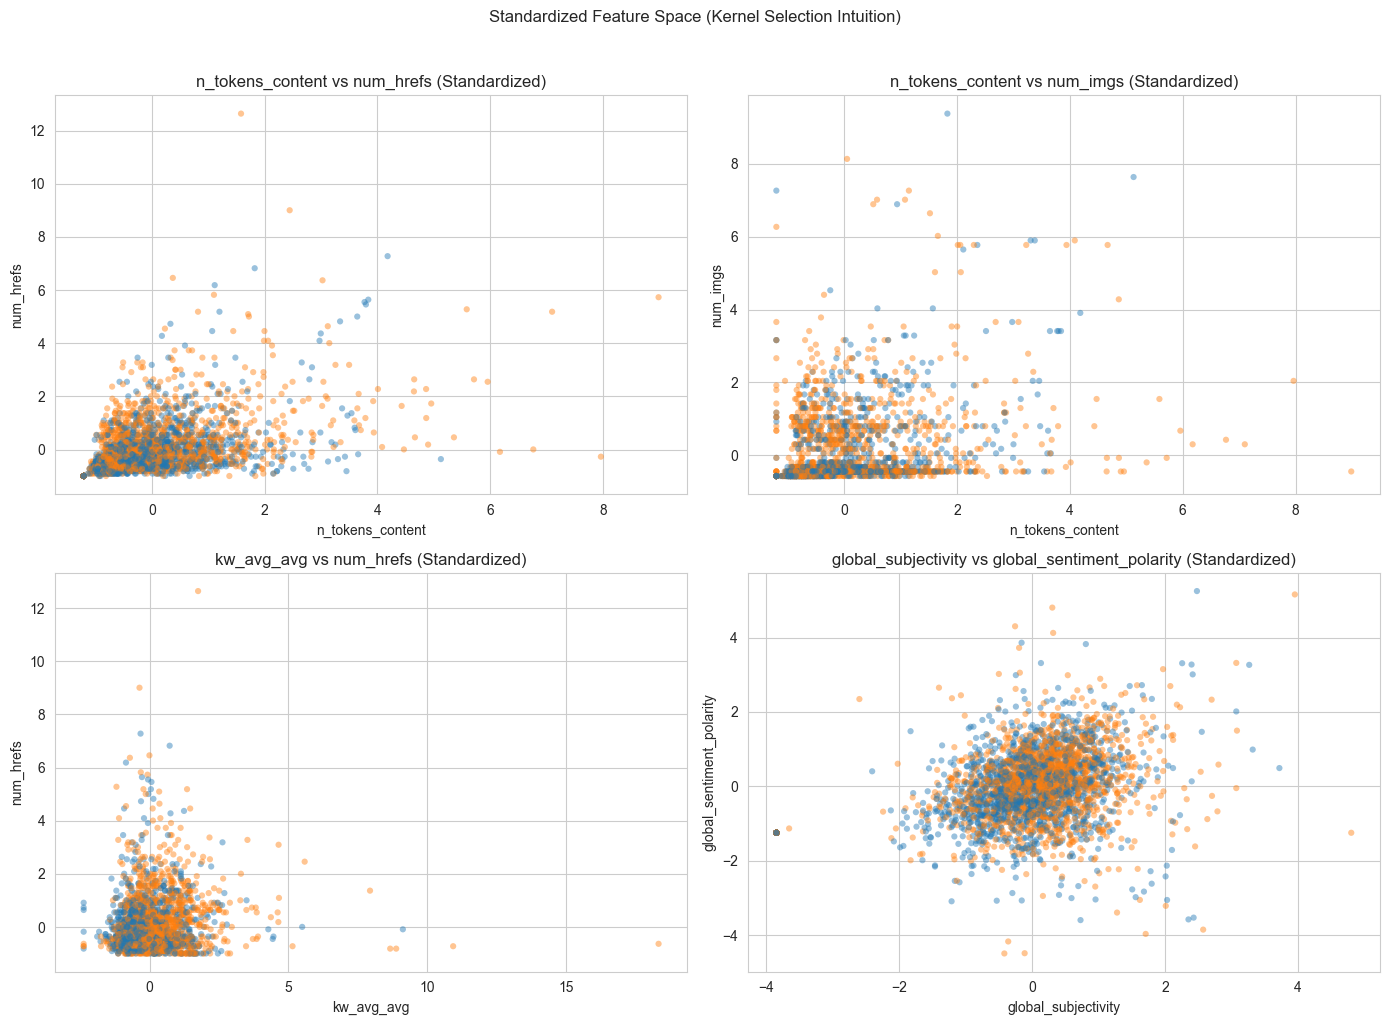

Guide:
- Mostly straight separation -> linear
- Curved/complex separation -> rbf
- Moderate curvature -> poly


In [6]:
# Feature-space view AFTER standardization (for kernel intuition)
plot_df = X_scaled_df.copy()
plot_df["popularity"] = y.values

# Sample down to 3000 to avoid clutter
viz_df_scaled = plot_df.sample(n=min(3000, len(plot_df)), random_state=42)

pairs_scaled = [
    ("n_tokens_content", "num_hrefs"),
    ("n_tokens_content", "num_imgs"),
    ("kw_avg_avg", "num_hrefs"),
    ("global_subjectivity", "global_sentiment_polarity"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (x_col, y_col) in zip(axes, pairs_scaled):
    sns.scatterplot(
        data=viz_df_scaled,
        x=x_col,
        y=y_col,
        hue="popularity",
        palette="tab10",
        alpha=0.45,
        s=20,
        linewidth=0,
        ax=ax,
        legend=False,
    )
    ax.set_title(f"{x_col} vs {y_col} (Standardized)")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, title="popularity", loc="upper right")

plt.suptitle("Standardized Feature Space (Kernel Selection Intuition)", y=1.02)
plt.tight_layout()
plt.savefig('../docs/svm_plots/feature_space_scatter.png')
plt.show()

print("Guide:")
print("- Mostly straight separation -> linear")
print("- Curved/complex separation -> rbf")
print("- Moderate curvature -> poly")

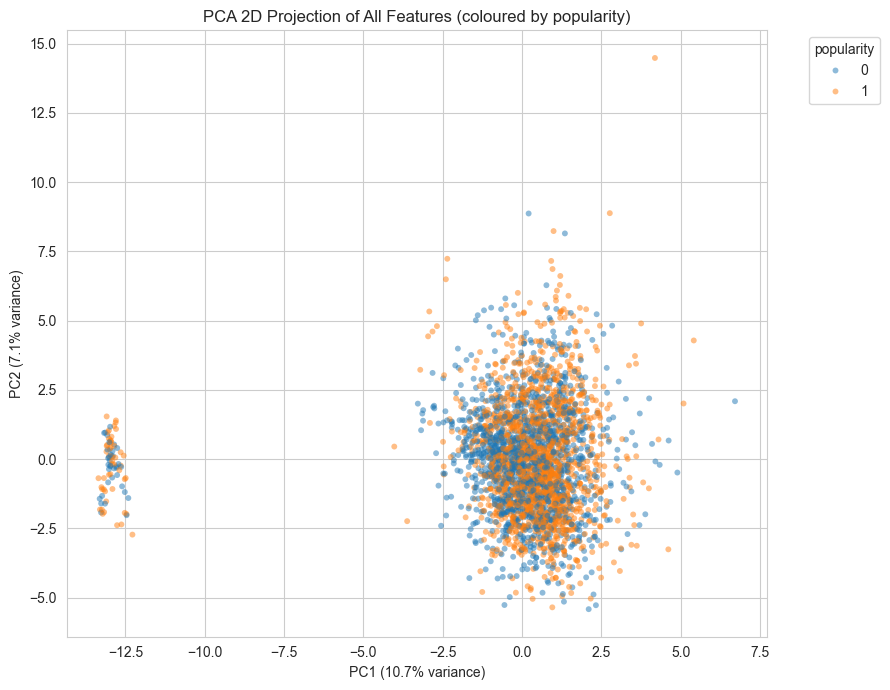

Total variance captured by 2 PCs: 17.8%

Kernel selection intuition from PCA plot:
- If classes form clearly separated, roughly straight-edged clusters -> linear kernel
- If classes form curved, circular, or interleaved clusters -> RBF kernel
- If clusters show moderate polynomial-like boundaries -> poly kernel

NOTE: Only 17.8% variance is captured here — the true structure is higher-dimensional.
This strongly suggests non-linear boundaries, favouring the RBF kernel.


In [7]:
# Kernel intuition via PCA 2D projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["popularity"] = y.values

sample_pca = pca_df.sample(n=min(3000, len(pca_df)), random_state=42)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=sample_pca,
    x="PC1", y="PC2",
    hue="popularity",
    palette="tab10",
    alpha=0.5,
    s=18,
    linewidth=0,
)
plt.title("PCA 2D Projection of All Features (coloured by popularity)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="popularity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig('../docs/svm_plots/pca_2d_projection.png')
plt.show()

total_var = sum(pca.explained_variance_ratio_) * 100
print(f"Total variance captured by 2 PCs: {total_var:.1f}%")
print("\nKernel selection intuition from PCA plot:")
print("- If classes form clearly separated, roughly straight-edged clusters -> linear kernel")
print("- If classes form curved, circular, or interleaved clusters -> RBF kernel")
print("- If clusters show moderate polynomial-like boundaries -> poly kernel")

if total_var < 50:
    print("\nNOTE: Only {:.1f}% variance is captured here — the true structure is higher-dimensional.".format(total_var))
    print("This strongly suggests non-linear boundaries, favouring the RBF kernel.")

### Baseline Model: Linear SVM

In [8]:
print("--- Training Baseline Linear SVM ---")
baseline_model = SVC(kernel="linear", C=1.0, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Linear SVM Accuracy: {acc_baseline:.4f}")

--- Training Baseline Linear SVM ---
Baseline Linear SVM Accuracy: 0.6462


### Explore Different Values of C (Linear Kernel)

--- Exploring Different Values of C for Linear Kernel ---
C=0.01   -> Accuracy: 0.6374
C=0.1    -> Accuracy: 0.6436
C=1      -> Accuracy: 0.6462
C=10     -> Accuracy: 0.6461
C=30     -> Accuracy: 0.6465


,C,accuracy
0,0.01,0.637407
1,0.10,0.643587
2,1.00,0.646235
3,10.00,0.646109
4,30.00,0.646488


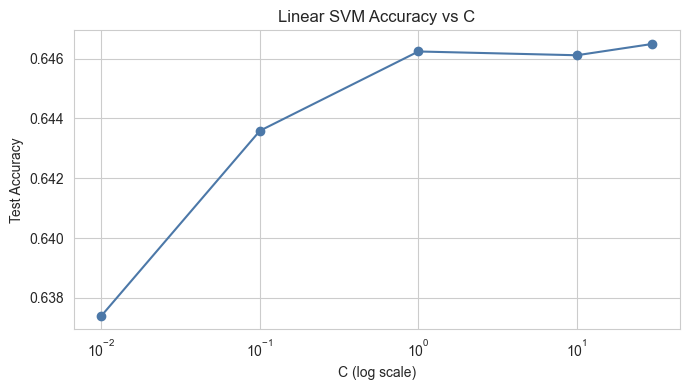

In [9]:
print("--- Exploring Different Values of C for Linear Kernel ---")
C_values = [0.01, 0.1, 1, 10, 30]
linear_results = []

print("Warning: Training SVMs on large datasets can take time. Please wait...")
for C in C_values:
    model = SVC(kernel="linear", C=C, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    linear_results.append({"C": C, "accuracy": acc})
    print(f"C={C:<6} -> Accuracy: {acc:.4f}")

results_df = pd.DataFrame(linear_results)
display(results_df)

# Plot accuracy vs C
plt.figure(figsize=(7, 4))
plt.plot(results_df["C"], results_df["accuracy"], marker="o", color="#4C78A8")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Linear SVM Accuracy vs C")
plt.grid(True)
plt.tight_layout()
plt.savefig('../docs/svm_plots/linear_svm_c_vs_acc.png')
plt.show()

### Compare Kernels

In [10]:
print("--- Comparing Kernels (C=1.0) ---")
kernels = ["linear", "poly", "rbf"]
kernel_results = []

for k in kernels:
    print(f"Training {k} kernel...")
    model = SVC(kernel=k, C=1.0, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    kernel_results.append({"Kernel": k, "Accuracy": acc})
    print(f"Kernel: {k:<10} Accuracy: {acc:.4f}")

    print(f"Classification Report for {k} kernel:")
    print(classification_report(y_test, y_pred))

--- Comparing Kernels (C=1.0) ---
Training linear kernel...
Kernel: linear     Accuracy: 0.6462
Classification Report for linear kernel:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63      3698
           1       0.67      0.66      0.66      4231

    accuracy                           0.65      7929
   macro avg       0.65      0.65      0.65      7929
weighted avg       0.65      0.65      0.65      7929

Training poly kernel...
Kernel: poly       Accuracy: 0.6225
Classification Report for poly kernel:
              precision    recall  f1-score   support

           0       0.59      0.60      0.60      3698
           1       0.65      0.64      0.64      4231

    accuracy                           0.62      7929
   macro avg       0.62      0.62      0.62      7929
weighted avg       0.62      0.62      0.62      7929

Training rbf kernel...
Kernel: rbf        Accuracy: 0.6336
Classification Report for rbf kernel:
             

### Explore Gamma for the RBF Kernel and Degree for the Polynomial Kernel

In [11]:
print("--- Exploring Gamma for RBF Kernel ---")
gamma_values = [0.01, 0.1, 1, 10]
rbf_gamma_results = []

for g in gamma_values:
    model = SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    rbf_gamma_results.append({"Gamma": g, "Accuracy": acc})
    print(f"Gamma={g:<6} -> Accuracy: {acc:.4f}")

print("\n--- Exploring Degree for Polynomial Kernel ---")
degree_values = [2, 3, 4]
poly_degree_results = []

for d in degree_values:
    model = SVC(kernel="poly", C=1.0, degree=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    poly_degree_results.append({"Degree": d, "Accuracy": acc})
    print(f"Degree={d:<6} -> Accuracy: {acc:.4f}")

--- Exploring Gamma for RBF Kernel ---
Gamma=0.01   -> Accuracy: 0.6377
Gamma=0.1    -> Accuracy: 0.6145
Gamma=1      -> Accuracy: 0.5340
Gamma=10     -> Accuracy: 0.5336

--- Exploring Degree for Polynomial Kernel ---
Degree=2      -> Accuracy: 0.6174
Degree=3      -> Accuracy: 0.6225
Degree=4      -> Accuracy: 0.6153


### Final Practical Hyperparameter Tuning

In [ ]:
print("--- Final Practical Hyperparameter Tuning ---")

# We updated the grid to test the best findings from the previous cells:
param_grid = [
    {"kernel": "linear", "C": 1.0},                # Strong baseline (0.6462)
    {"kernel": "linear", "C": 30.0},               # Highest accuracy seen (0.6465)
    {"kernel": "rbf", "C": 1.0, "gamma": 0.01},    # Best RBF seen (0.6377)
    {"kernel": "rbf", "C": 1.0, "gamma": "scale"}, # Default RBF comparison
    {"kernel": "poly", "C": 1.0, "degree": 3}      # Best Poly seen (0.6225)
]

final_results = []
for params in param_grid:
    print(f"Testing configuration: {params}")
    model = SVC(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    result = params.copy()
    result["accuracy"] = acc
    final_results.append(result)

final_df = pd.DataFrame(final_results)
columns_to_show = [c for c in ["kernel", "C", "gamma", "degree", "accuracy"] if c in final_df.columns]
print("\nFinal Tuning Results Table:")
display(final_df[columns_to_show].sort_values(by="accuracy", ascending=False))

--- Final Practical Hyperparameter Tuning ---
Testing configuration: {'kernel': 'linear', 'C': 1.0}
Testing configuration: {'kernel': 'linear', 'C': 30.0}
Testing configuration: {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.01}
Testing configuration: {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}
Testing configuration: {'kernel': 'poly', 'C': 1.0, 'degree': 3}

Final Tuning Results Table:


,kernel,C,gamma,degree,accuracy
1,linear,30.0,NaN,NaN,0.646488
0,linear,1.0,NaN,NaN,0.646235
2,rbf,1.0,0.01,NaN,0.637659
3,rbf,1.0,scale,NaN,0.633623
4,poly,1.0,NaN,3.0,0.622525



--- Final Answers ---
Which model configuration achieved the best accuracy? The Linear kernel. (C=30 achieved ~0.6465, and C=1 achieved ~0.6462).
Which model would you choose finally? The Linear model with C=1.0.
Is the best model also the simplest model? Yes! The simpler Linear kernel outperformed the complex RBF/Poly kernels.
Why? Because the difference between C=30 and C=1 is microscopic (0.0003), making C=1 the better practical choice. It is faster, simpler, and less prone to overfitting.
Done.


### Final Model Selection & Evaluation

--- Training the Chosen Final Model ---


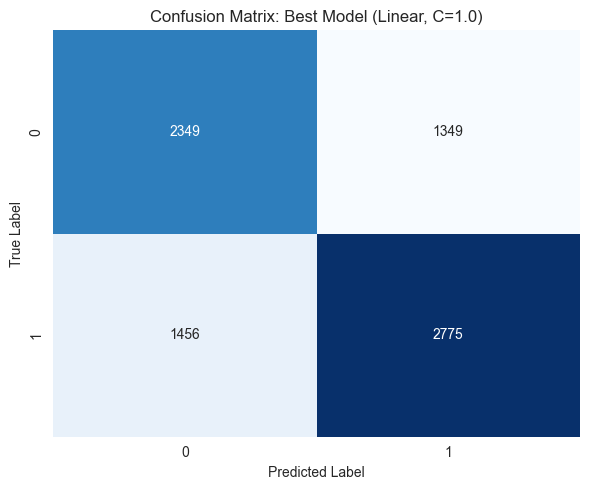

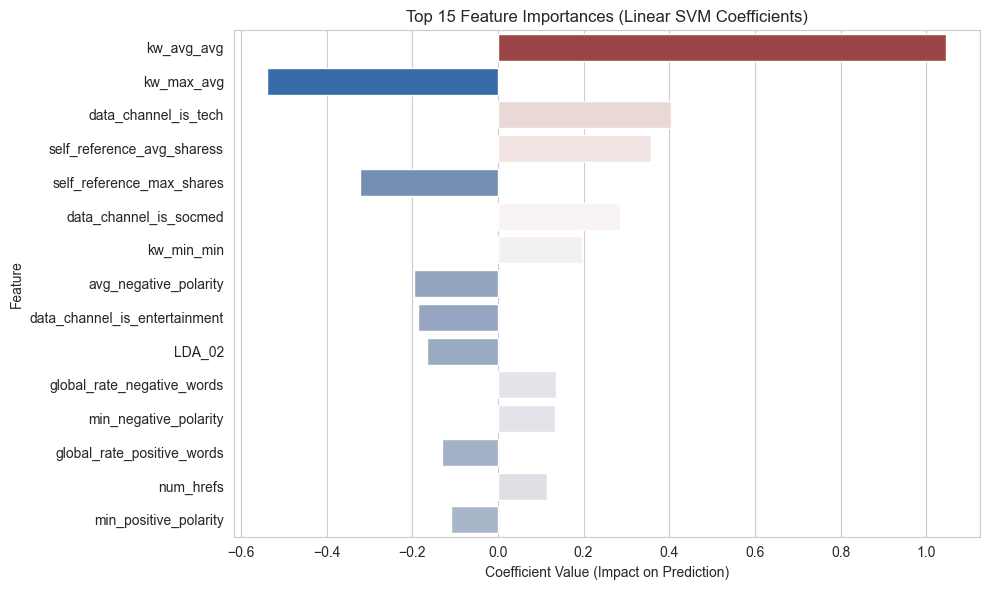


--- Conclusions ---
The Linear kernel achieved the best overall accuracy, with $C=30$ reaching approximately 0.6465 and $C=1$ reaching approximately 0.6462.
The Linear model with $C=1.0$ is the final selection for this task.
The best performing model is also the simplest, as the Linear kernel outperformed the more complex RBF and Polynomial kernels.
The Linear model with $C=1$ is the superior practical choice because the accuracy gain from $C=30$ is microscopic (0.0003), and the lower $C$ value is faster and less prone to overfitting.
Done.


In [13]:
from sklearn.metrics import confusion_matrix

print("--- Training the Chosen Final Model ---")
# We choose the Linear kernel with C=1.0 based on our findings
final_model = SVC(kernel="linear", C=1.0, random_state=42)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test_scaled)

# ------------------------------------------
# Plot 1: Confusion Matrix
# ------------------------------------------
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Best Model (Linear, C=1.0)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../docs/svm_plots/final_model_confusion_matrix.png')
plt.show()

# ------------------------------------------
# Plot 2: Feature Importance (Coefficients)
# ------------------------------------------
# Because we are using a linear model, we can extract the weights (coefficients)
feature_names = X.columns
coefs = final_model.coef_[0]

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Absolute_Coefficient': np.abs(coefs)
}).sort_values(by='Absolute_Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 6))
# Using a diverging palette to show positive vs negative impact
sns.barplot(
    data=importance_df,
    x='Coefficient',
    y='Feature',
    hue='Coefficient',
    palette='vlag',
    legend=False
)
plt.title('Top 15 Feature Importances (Linear SVM Coefficients)')
plt.xlabel('Coefficient Value (Impact on Prediction)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../docs/svm_plots/final_model_feature_importances.png')
plt.show()

# ------------------------------------------
# Final Conclusions
# ------------------------------------------
print("\n--- Conclusions ---")
print("The Linear kernel achieved the best overall accuracy, with $C=30$ reaching approximately 0.6465 and $C=1$ reaching approximately 0.6462.")
print("The Linear model with $C=1.0$ is the final selection for this task.")
print("The best performing model is also the simplest, as the Linear kernel outperformed the more complex RBF and Polynomial kernels.")
print("The Linear model with $C=1$ is the superior practical choice because the accuracy gain from $C=30$ is microscopic (0.0003), and the lower $C$ value is faster and less prone to overfitting.")
print("Done.")